# 01. ROSE and LROM for a Single Scattering Wavefunction

This notebook is the first end-to-end demonstration of the stateful
`lrom.LROM` API. It compares high-fidelity solutions of the nuclear
scattering equation with ROSE/RBM and LROM approximations for the
exact $l=0$ channel of $^{40}$Ca(n,n) at 14.1 MeV.

All horizontal axes use physical radius $r$ in fm. The LROM
calculations use the public v1.2 `lrom` package.
ROSE and LROM use the same high-fidelity training snapshots and retained rank,
but they use different reference functions: LROM is centered on the central
potential solution, while ROSE is centered on the free solution required by
its reduced-basis equations. Their reconstructed wavefunctions can be compared;
their coefficient values belong to different coordinate systems and are shown
separately.

## Notebook inputs

Two independent objects make the scientific distinction explicit:

- `vv_emulator`: `ws_1`, a Vv-only linspace study with normalized parameter predictors.
- `ws3_emulator`: `ws_3`, a Vv/Rv/av Latin-hypercube study with six selected potential predictors.

Both use a four-vector wavefunction basis and an eight-vector EIM basis.
Training and testing domains are deliberately separate so interpolation
and extrapolation behavior can be examined.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from numba import njit
import numpy as np
import pandas as pd

ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "lrom").is_dir()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

for name in list(sys.modules):
    if name in ("lrom", "lrom_legacy") or name.startswith(("lrom.", "lrom_legacy.")):
        del sys.modules[name]

import scipy.special
if not hasattr(scipy.special, "sph_harm") and hasattr(scipy.special, "sph_harm_y"):
    # legacy sph_harm took (theta=azimuthal, phi=polar); sph_harm_y takes (polar, azimuthal)
    scipy.special.sph_harm = lambda m, n, theta, phi: scipy.special.sph_harm_y(n, m, phi, theta)

import rose
import lrom

BASIS_SIZE = 4
DISPLAY_ERROR_FLOOR = 1e-11
METHOD_COLORS = {"ls": "blue", "lrom": "#E6AB02", "rose": "red"}
print("LROM package:", lrom.__version__)

@njit
def rose_real_woods_saxon(radius, alpha):
    # ROSE evaluates this exact callback for HF solves and builds its EIM from it.
    vv, rv, av = alpha
    return -vv / (1.0 + np.exp((radius - rv) / av))

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

LROM package: 1.2.0


## Section 1. Parameter Varying Vv

The first object isolates the effect of the real Woods-Saxon depth.
Its testing interval is wider than its training interval. The fixed
$R_v$ and $a_v$ values come from the Koning-Delaroche global
systematics for this target/projectile system at 14.1 MeV laboratory
energy; only $V_v$ varies in this teaching case.

In [2]:
vv_emulator = lrom.LROM(
    target=(40, 20),
    projectile=(1, 0),
    lab_energy=14.1,
    l=0,
    fom="nucl-scatter-eq",
    potential="ws_1",
)
vv_center = dict(vv_emulator.central_parameters)
Vv0 = vv_center["Vv"]
vv_training_ranges = {"Vv": (0.90 * Vv0, 1.10 * Vv0)}
vv_testing_ranges = {"Vv": (0.65 * Vv0, 1.35 * Vv0)}

# Public call: generate exact Runge-Kutta snapshots for the Vv design.
vv_emulator.sampling(
    training_ranges=vv_training_ranges,
    testing_ranges=vv_testing_ranges,
    training_size=35,
    testing_size=41,
    mesh_size=800,
    strategy="linspace",
    seed=1204,
    high_fidelity_solver="runge_kutta",
)
# Public call: train RF-LROM with one normalized Vv predictor.
vv_emulator.train(
    basis_size=BASIS_SIZE,
    predictor="parameters",
    predictor_count=1,
)

# LS is an explicit oracle benchmark: it projects the known testing
# wavefunctions onto the already-trained LROM basis.
vv_fom_train = vv_emulator.samples.training_wavefunctions[0]
vv_fom_test = vv_emulator.samples.testing_wavefunctions[0]
vv_ls_train_coefficients, vv_ls_train_wavefunctions = lrom.least_squares_baseline(
    basis=vv_emulator.basis[0],
    wavefunctions=vv_fom_train,
)
vv_ls_coefficients, vv_ls_wavefunctions = lrom.least_squares_baseline(
    basis=vv_emulator.basis[0],
    wavefunctions=vv_fom_test,
)
vv_ls_relative_l2 = lrom.relative_l2(
    prediction=vv_ls_wavefunctions,
    reference=vv_fom_test,
)

print("central parameters:", dict(vv_emulator.central_parameters))
print("Vv varies over the requested ranges")
print("fixed Rv [fm]:", vv_center["Rv"])
print("fixed av [fm]:", vv_center["av"])
print("training wavefunctions:", vv_emulator.samples.training_wavefunctions[0].shape)
print("testing wavefunctions:", vv_emulator.samples.testing_wavefunctions[0].shape)

# 1. Assemble the FOM parameter rows used to bound the ROSE EIM.
vv_central_row = np.asarray(
    [vv_center[name] for name in vv_emulator.parameter_names]
)
vv_rose_rows = np.vstack([
    vv_central_row,
    vv_emulator.samples.design.training.values,
    vv_emulator.samples.design.testing.values,
])
vv_rose_bounds = np.column_stack([
    vv_rose_rows.min(axis=0),
    vv_rose_rows.max(axis=0),
])

# 2. Initialize the notebook-owned EIM interaction.
vv_rose_interactions = rose.InteractionEIMSpace(
    l_max=0,
    coordinate_space_potential=rose_real_woods_saxon,
    n_theta=len(vv_emulator.parameter_names),
    mu=vv_emulator.kinematics.mu,
    energy=vv_emulator.kinematics.e_com,
    is_complex=False,
    training_info=vv_rose_bounds,
    n_basis=8,
    rho_mesh=vv_emulator.samples.mesh.rho,
)
vv_rose_interaction = vv_rose_interactions.interactions[0][0]

# 3. Produce ROSE's free solution and reduced basis.
vv_rose_phi0 = np.asarray([
    rose.free_solutions.phi_free(float(rho), 0, vv_emulator.kinematics.eta)
    for rho in vv_emulator.samples.mesh.rho
], dtype=np.complex128)
vv_rose_basis = rose.basis.CustomBasis(
    solutions=np.asarray(vv_emulator.samples.training_wavefunctions[0], dtype=np.complex128).T.copy(),
    phi_0=vv_rose_phi0.copy(),
    rho_mesh=vv_emulator.samples.mesh.rho,
    n_basis=BASIS_SIZE,
    solver=vv_emulator.full_order_model[0].solver,
    subtract_phi0=True,
    use_svd=True,
    center=False,
    scale=False,
)
vv_rose_rbe = rose.reduced_basis_emulator.ReducedBasisEmulator(
    vv_rose_interaction,
    vv_rose_basis,
    s_0=vv_emulator.full_order_model[0].base_solver.s_0,
    initialize_emulator=True,
)

# 4. Evaluate ROSE on the same ordered parameter rows as LS and LROM.
vv_train_rows = vv_emulator.samples.design.training.values
vv_test_rows = vv_emulator.samples.design.testing.values
vv_rose_train_coefficients = np.asarray([vv_rose_rbe.coefficients(row) for row in vv_train_rows])
vv_rose_coefficients = np.asarray([vv_rose_rbe.coefficients(row) for row in vv_test_rows])
vv_rose_wavefunctions = np.asarray([vv_rose_rbe.emulate_wave_function(row) for row in vv_test_rows])

central parameters: {'Vv': 48.822175142383706, 'Rv': 4.053875273743491, 'av': 0.671852}
Vv varies over the requested ranges
fixed Rv [fm]: 4.053875273743491
fixed av [fm]: 0.671852
training wavefunctions: (35, 800)
testing wavefunctions: (41, 800)


The potential rainbow shows the isolated change in depth, while the
wavefunction rainbow shows the corresponding high-fidelity response.
Both panels use the same training cases and physical radius mesh.

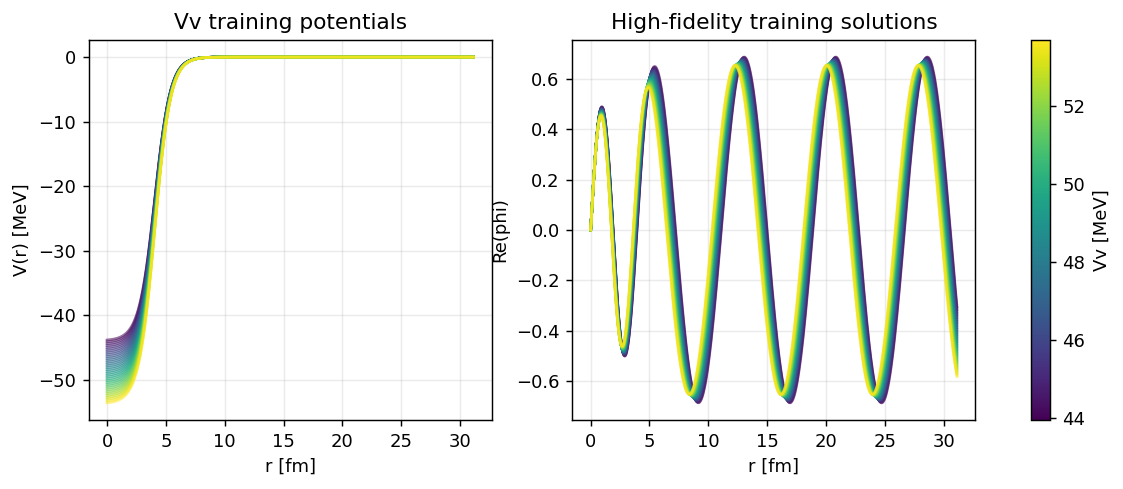

In [3]:
r = vv_emulator.mesh.radius
vv_values = vv_emulator.samples.design.training.values[:, 0]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
colors = plt.cm.viridis(np.linspace(0, 1, len(vv_values)))
for color, value, potential, phi in zip(
    colors,
    vv_values,
    vv_emulator.samples.training_potentials,
    vv_emulator.samples.training_wavefunctions[0],
):
    axes[0].plot(r, np.real(potential), color=color, alpha=0.55)
    axes[1].plot(r, np.real(phi), color=color, alpha=0.55)
axes[0].set(xlabel="r [fm]", ylabel="V(r) [MeV]", title="Vv training potentials")
axes[1].set(xlabel="r [fm]", ylabel="Re(phi)", title="High-fidelity training solutions")
fig.colorbar(
    plt.cm.ScalarMappable(
        norm=plt.Normalize(vv_values.min(), vv_values.max()), cmap="viridis"
    ),
    ax=axes,
    label="Vv [MeV]",
)
plt.show()

The next figure places the LROM central-reference basis beside the ROSE
free-reference basis. Their coordinates use different reference
functions, so the basis labels remain distinct.

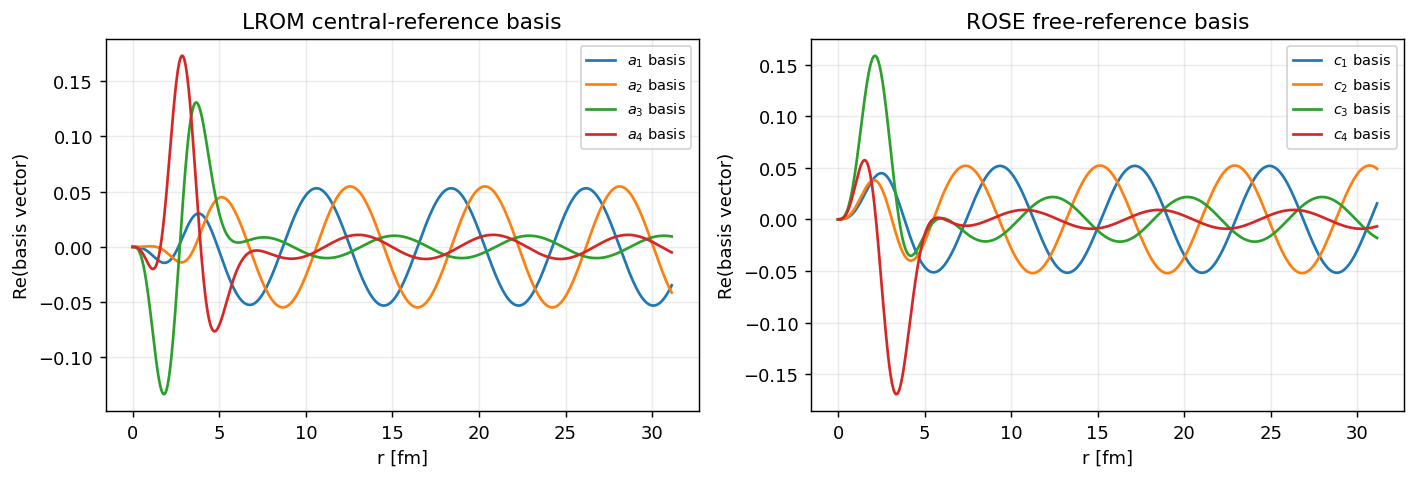

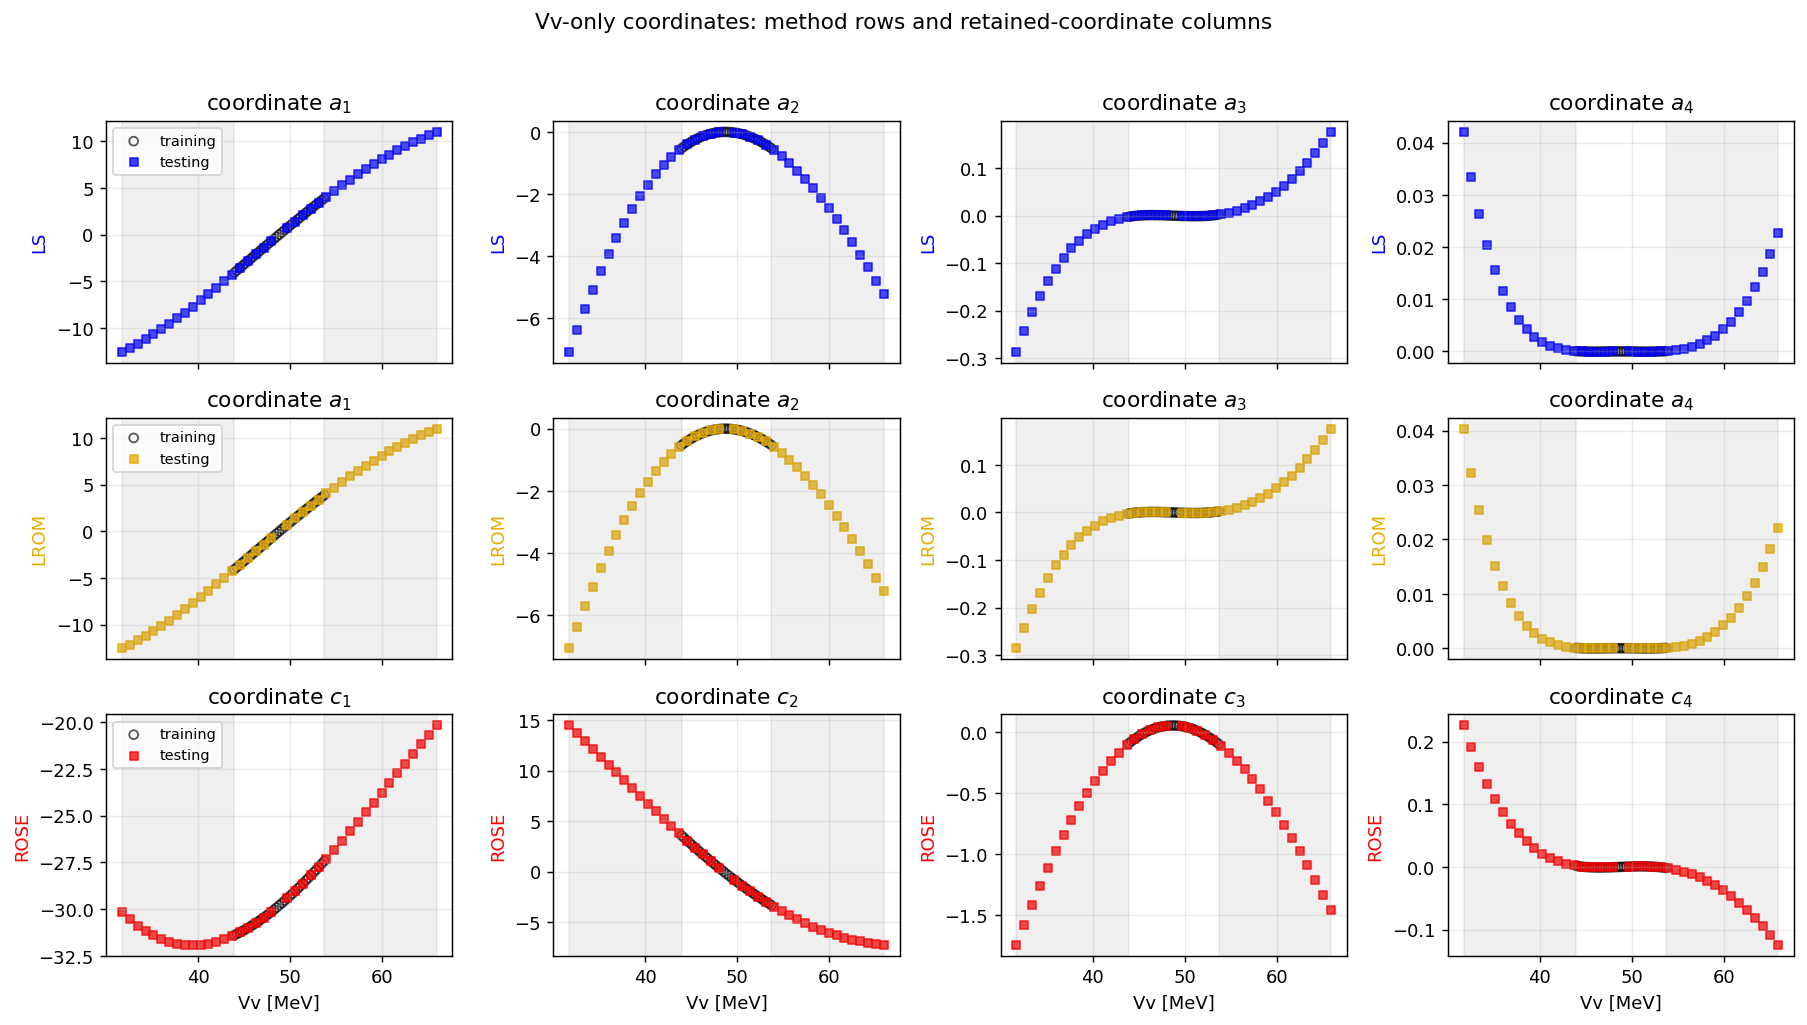

In [4]:
basis = vv_emulator.basis[0]
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.8))
for coordinate_index in range(BASIS_SIZE):
    axes[0].plot(
        r,
        np.real(basis.vectors[:, coordinate_index]),
        label=fr"$a_{{{coordinate_index + 1}}}$ basis",
    )
    axes[1].plot(
        r,
        np.real(vv_rose_basis.vectors[:, coordinate_index]),
        label=fr"$c_{{{coordinate_index + 1}}}$ basis",
    )
axes[0].set(
    xlabel="r [fm]",
    ylabel="Re(basis vector)",
    title="LROM central-reference basis",
)
axes[1].set(
    xlabel="r [fm]",
    ylabel="Re(basis vector)",
    title="ROSE free-reference basis",
)
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

# Put every method on the same physical Vv axis. Open circles are
# training coordinates; colored squares are noncentral test coordinates.
vv_train = vv_train_rows[:, 0]
vv_test = vv_test_rows[:, 0]
vv_plot_mask = ~np.isclose(vv_test, Vv0, rtol=0.0, atol=1e-12)
vv_coordinate_data = {
    "LS": {
        "training": vv_ls_train_coefficients,
        "testing": vv_ls_coefficients,
        "symbol": "a",
        "color": METHOD_COLORS["ls"],
    },
    "LROM": {
        "training": np.asarray(
            vv_emulator.training_results.coefficients["lrom"][0]
        ),
        "testing": np.asarray(
            vv_emulator.testing_results.coefficients["lrom"][0]
        ),
        "symbol": "a",
        "color": METHOD_COLORS["lrom"],
    },
    "ROSE": {
        "training": vv_rose_train_coefficients,
        "testing": vv_rose_coefficients,
        "symbol": "c",
        "color": METHOD_COLORS["rose"],
    },
}
vv_train_low, vv_train_high = vv_training_ranges["Vv"]
fig, axes = plt.subplots(3, BASIS_SIZE, figsize=(14.0, 8.0), sharex="col")
for row_index, (method, coordinate_data) in enumerate(
    vv_coordinate_data.items()
):
    for coordinate_index in range(BASIS_SIZE):
        ax = axes[row_index, coordinate_index]
        ax.scatter(
            vv_train,
            np.real(coordinate_data["training"][:, coordinate_index]),
            s=24,
            marker="o",
            facecolors="none",
            edgecolors="black",
            alpha=0.65,
            label="training" if coordinate_index == 0 else None,
        )
        ax.scatter(
            vv_test[vv_plot_mask],
            np.real(
                coordinate_data["testing"][vv_plot_mask, coordinate_index]
            ),
            s=24,
            marker="s",
            color=coordinate_data["color"],
            alpha=0.75,
            label="testing" if coordinate_index == 0 else None,
        )
        ax.axvspan(vv_test.min(), vv_train_low, color="gray", alpha=0.12)
        ax.axvspan(vv_train_high, vv_test.max(), color="gray", alpha=0.12)
        ax.set_title(fr"coordinate ${coordinate_data['symbol']}_{{{coordinate_index + 1}}}$")
        ax.set_ylabel(method, color=coordinate_data["color"])
        if row_index == len(vv_coordinate_data) - 1:
            ax.set_xlabel("Vv [MeV]")
    axes[row_index, 0].legend(fontsize=8)
fig.suptitle("Vv-only coordinates: method rows and retained-coordinate columns")
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

Three matched testing cases replace an arbitrary representative row.
First remove near-central cases and any testing row that duplicates a
training row. Then rank each remaining row independently by LS, LROM,
and ROSE relative error. The mean of those three ranks defines a
method-neutral difficulty order; the displayed columns are nearest its
25th, 50th, and 75th percentiles.

,case_id,Vv [MeV],LS relative L2,LROM relative L2,ROSE relative L2
difficulty,,,,,
lower,test-0011,41.132683,0.000004,0.000005,0.000799
median,test-0033,59.929220,0.000026,0.000034,0.003239
upper,test-0037,63.346772,0.000100,0.000156,0.008757


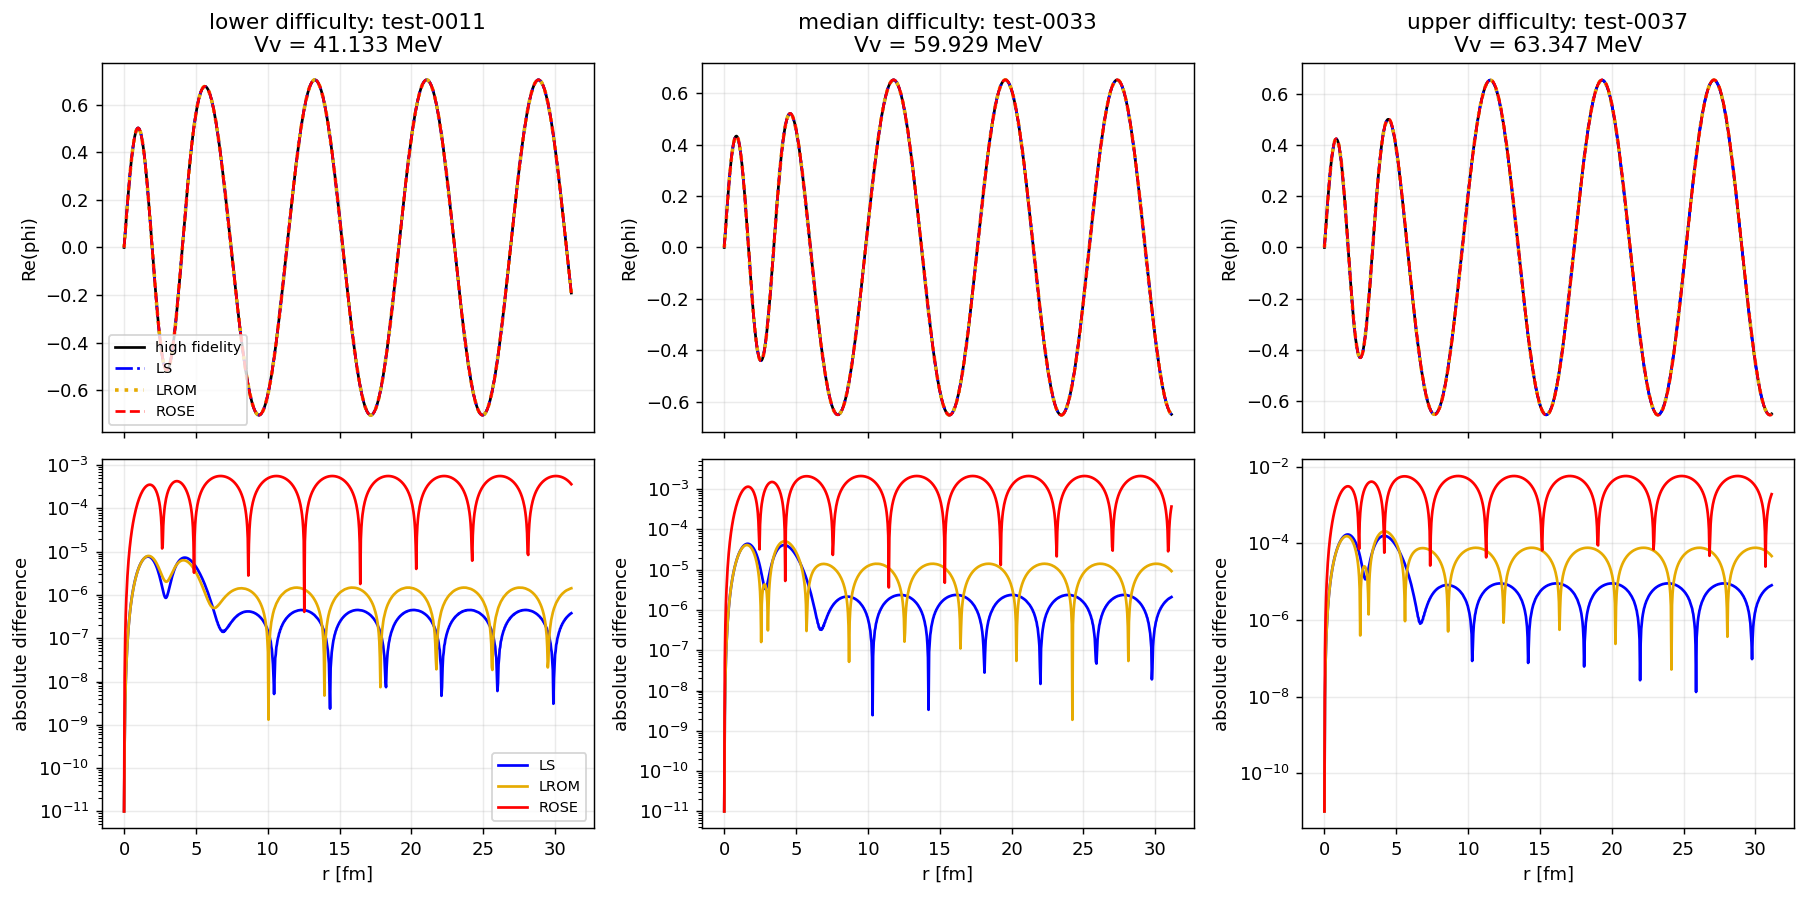

In [5]:
# Assemble one error row per testing case in the fixed LS/LROM/ROSE order.
vv_case_errors = np.column_stack((
    vv_ls_relative_l2,
    np.asarray(vv_emulator.testing_results.metrics["relative_l2"][0]["lrom"]),
    lrom.relative_l2(
        prediction=vv_rose_wavefunctions,
        reference=vv_fom_test,
    ),
))

# Exclude cases close to the central reference and exact train/test overlaps.
vv_testing_half_range = 0.5 * (
    vv_testing_ranges["Vv"][1] - vv_testing_ranges["Vv"][0]
)
vv_normalized_distance = np.abs(vv_test - Vv0) / vv_testing_half_range
vv_training_overlap = np.any(
    np.isclose(
        vv_test[:, None],
        vv_train[None, :],
        rtol=0.0,
        atol=1e-12,
    ),
    axis=1,
)
vv_candidate_indices = np.flatnonzero(
    (vv_normalized_distance >= 0.25) & ~vv_training_overlap
)
assert len(vv_candidate_indices) >= 3

# Rank eligible rows separately for each method, then average the ranks.
vv_candidate_errors = vv_case_errors[vv_candidate_indices]
vv_method_ranks = np.empty_like(vv_candidate_errors, dtype=float)
for method_index in range(vv_candidate_errors.shape[1]):
    method_order = np.argsort(
        vv_candidate_errors[:, method_index], kind="stable"
    )
    vv_method_ranks[method_order, method_index] = np.arange(
        len(vv_candidate_indices)
    )
vv_combined_rank = vv_method_ranks.mean(axis=1)
vv_difficulty_order = vv_candidate_indices[
    np.argsort(vv_combined_rank, kind="stable")
]
vv_difficulty_quantiles = np.array([0.25, 0.50, 0.75])
vv_selected_positions = np.rint(
    vv_difficulty_quantiles * (len(vv_difficulty_order) - 1)
).astype(int)
vv_selected_indices = vv_difficulty_order[vv_selected_positions]
assert len(np.unique(vv_selected_indices)) == 3
assert np.all(vv_normalized_distance[vv_selected_indices] >= 0.25)
assert not np.any(vv_training_overlap[vv_selected_indices])

# Verify that case IDs, parameter rows, and every method use the same index.
vv_selected_ids = np.asarray(
    vv_emulator.samples.design.testing.case_ids
)[vv_selected_indices]
vv_difficulty_labels = ("lower", "median", "upper")
vv_selected_records = []
for difficulty_label, selected_index, selected_id in zip(
    vv_difficulty_labels, vv_selected_indices, vv_selected_ids
):
    vv_case = vv_emulator.testing_case(case_id=selected_id)
    case_row = np.asarray([
        vv_case.parameters[name] for name in vv_emulator.parameter_names
    ])
    assert np.allclose(case_row, vv_test_rows[selected_index])
    vv_selected_records.append({
        "difficulty": difficulty_label,
        "case_id": selected_id,
        "Vv [MeV]": float(vv_test_rows[selected_index, 0]),
        "LS relative L2": float(vv_case_errors[selected_index, 0]),
        "LROM relative L2": float(vv_case_errors[selected_index, 1]),
        "ROSE relative L2": float(vv_case_errors[selected_index, 2]),
    })
display(pd.DataFrame(vv_selected_records).set_index("difficulty"))

# Each column now compares the same physical case across all methods.
fig, axes = plt.subplots(2, 3, figsize=(14.0, 7.0), sharex="col")
for column, (difficulty_label, selected_index, selected_id) in enumerate(
    zip(vv_difficulty_labels, vv_selected_indices, vv_selected_ids)
):
    vv_case = vv_emulator.testing_case(case_id=selected_id)
    axes[0, column].plot(
        vv_case.radius,
        np.real(vv_case.high_fidelity[0]),
        color="black",
        label="high fidelity",
    )
    axes[0, column].plot(
        vv_case.radius,
        np.real(vv_ls_wavefunctions[selected_index]),
        "-.",
        color=METHOD_COLORS["ls"],
        label="LS",
    )
    axes[0, column].plot(
        vv_case.radius,
        np.real(vv_case.lrom[0]),
        ":",
        color=METHOD_COLORS["lrom"],
        linewidth=2,
        label="LROM",
    )
    axes[0, column].plot(
        vv_case.radius,
        np.real(vv_rose_wavefunctions[selected_index]),
        "--",
        color=METHOD_COLORS["rose"],
        label="ROSE",
    )
    axes[0, column].set(
        ylabel="Re(phi)",
        title=(
            f"{difficulty_label} difficulty: {selected_id}\n"
            f"Vv = {vv_test_rows[selected_index, 0]:.3f} MeV"
        ),
    )
    axes[1, column].plot(
        vv_case.radius,
        np.maximum(
            np.abs(
                vv_case.high_fidelity[0]
                - vv_ls_wavefunctions[selected_index]
            ),
            DISPLAY_ERROR_FLOOR,
        ),
        color=METHOD_COLORS["ls"],
        label="LS",
    )
    axes[1, column].plot(
        vv_case.radius,
        np.maximum(
            np.abs(vv_case.high_fidelity[0] - vv_case.lrom[0]),
            DISPLAY_ERROR_FLOOR,
        ),
        color=METHOD_COLORS["lrom"],
        label="LROM",
    )
    axes[1, column].plot(
        vv_case.radius,
        np.maximum(
            np.abs(
                vv_case.high_fidelity[0]
                - vv_rose_wavefunctions[selected_index]
            ),
            DISPLAY_ERROR_FLOOR,
        ),
        color=METHOD_COLORS["rose"],
        label="ROSE",
    )
    axes[1, column].set_yscale("log")
    axes[1, column].set(
        xlabel="r [fm]",
        ylabel="absolute difference",
    )
axes[0, 0].legend(fontsize=8)
axes[1, 0].legend(fontsize=8)
fig.tight_layout()
plt.show()

Finally, the pointwise error family shows how each approximation
behaves across every noncentral Vv testing case.

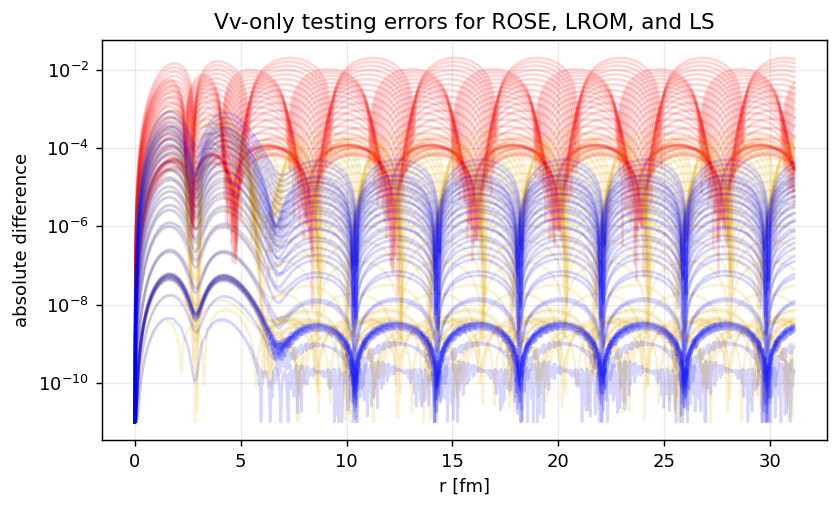

In [6]:
vv_errors = dict(vv_emulator.testing_errors[0])
vv_errors["ls"] = np.abs(vv_ls_wavefunctions - vv_fom_test)
vv_errors["rose"] = np.abs(vv_rose_wavefunctions - vv_fom_test)
fig, ax = plt.subplots(figsize=(7.2, 4.0))
for method in ("rose", "lrom", "ls"):
    for error in vv_errors[method][vv_plot_mask]:
        ax.plot(r, np.maximum(error, DISPLAY_ERROR_FLOOR), color=METHOD_COLORS[method], alpha=0.16)
ax.set_yscale("log")
ax.set_xlabel("r [fm]")
ax.set_ylabel("absolute difference")
ax.set_title("Vv-only testing errors for ROSE, LROM, and LS")
plt.show()

## Section 2. Three-Parameter LROM Equation And Predictor Selection

The second object varies Vv, Rv, and av together. Its default potential
predictors are values of the Woods-Saxon potential at six physical radii
selected from the training ensemble by SVD and maxvol-style selection.

The transformed equation has the form
$(I + \sum_{j=1}^{K}p_j(\alpha)M_j)a(\alpha)
= \sum_{j=1}^{K}p_j(\alpha)b_j$, where $\alpha=(V_v,R_v,a_v)$
is the physical parameter vector. We first fit raw parameter predictors
as a diagnostic, then refit the same snapshots with potential predictors.
This tests the predictor choice without rerunning the FOM.
The constant source $b_0$ is identically zero here because the
predictors and the reduced coordinates are both centered on the
reference solution: $p = 0$ must give $a = 0$.

In [7]:
ws3_emulator = lrom.LROM(
    target=(40, 20),
    projectile=(1, 0),
    lab_energy=14.1,
    l=0,
    fom="nucl-scatter-eq",
    potential="ws_3",
)
ws3_center = dict(ws3_emulator.central_parameters)
ws3_training_ranges = {
    name: (0.90 * ws3_center[name], 1.10 * ws3_center[name])
    for name in ("Vv", "Rv", "av")
}
ws3_testing_ranges = {
    "Vv": (0.78 * ws3_center["Vv"], 1.22 * ws3_center["Vv"]),
    "Rv": (0.80 * ws3_center["Rv"], 1.20 * ws3_center["Rv"]),
    "av": (0.80 * ws3_center["av"], 1.20 * ws3_center["av"]),
}

# Public call: sample the three-parameter physical region once.
ws3_emulator.sampling(
    training_ranges=ws3_training_ranges,
    testing_ranges=ws3_testing_ranges,
    training_size=70,
    testing_size=81,
    mesh_size=800,
    strategy="latin_hypercube",
    seed=1204,
    high_fidelity_solver="runge_kutta",
)
# Diagnostic fit: preserve raw parameter predictors before retraining.
ws3_emulator.train(
    basis_size=BASIS_SIZE,
    predictor="parameters",
    predictor_count=3,
)
parameter_lrom = np.asarray(
    ws3_emulator.testing_results.lrom[0]
).copy()
parameter_relative_l2 = np.asarray(
    ws3_emulator.testing_results.metrics["relative_l2"][0]["lrom"]
).copy()
parameter_training_relative_l2 = np.asarray(
    ws3_emulator.training_results.metrics["relative_l2"][0]["lrom"]
).copy()

# Main fit: reuse the same FOM snapshots with potential predictors.
ws3_emulator.train(
    basis_size=BASIS_SIZE,
    predictor="potential",
    predictor_count=6,
)

# Compute the optional LS floor explicitly for both sample sets.
ws3_fom_train = ws3_emulator.samples.training_wavefunctions[0]
ws3_fom_test = ws3_emulator.samples.testing_wavefunctions[0]
ws3_ls_train_coefficients, ws3_ls_wf_train = lrom.least_squares_baseline(
    basis=ws3_emulator.basis[0],
    wavefunctions=ws3_fom_train,
)
ws3_ls_coefficients, ws3_ls_wf_test = lrom.least_squares_baseline(
    basis=ws3_emulator.basis[0],
    wavefunctions=ws3_fom_test,
)
ws3_ls_rel_train = lrom.relative_l2(
    prediction=ws3_ls_wf_train,
    reference=ws3_fom_train,
)
ws3_ls_rel_test = lrom.relative_l2(
    prediction=ws3_ls_wf_test,
    reference=ws3_fom_test,
)

# 1. Assemble the FOM parameter rows used to bound the ROSE EIM.
ws3_central_row = np.asarray(
    [ws3_center[name] for name in ws3_emulator.parameter_names]
)
ws3_rose_rows = np.vstack([
    ws3_central_row,
    ws3_emulator.samples.design.training.values,
    ws3_emulator.samples.design.testing.values,
])
ws3_rose_bounds = np.column_stack([
    ws3_rose_rows.min(axis=0),
    ws3_rose_rows.max(axis=0),
])

# 2. Initialize the notebook-owned EIM interaction.
ws3_rose_interactions = rose.InteractionEIMSpace(
    l_max=0,
    coordinate_space_potential=rose_real_woods_saxon,
    n_theta=len(ws3_emulator.parameter_names),
    mu=ws3_emulator.kinematics.mu,
    energy=ws3_emulator.kinematics.e_com,
    is_complex=False,
    training_info=ws3_rose_bounds,
    n_basis=8,
    rho_mesh=ws3_emulator.samples.mesh.rho,
)
ws3_rose_interaction = ws3_rose_interactions.interactions[0][0]

# 3. Produce ROSE's free solution and reduced basis.
ws3_rose_phi0 = np.asarray([
    rose.free_solutions.phi_free(float(rho), 0, ws3_emulator.kinematics.eta)
    for rho in ws3_emulator.samples.mesh.rho
], dtype=np.complex128)
ws3_rose_basis = rose.basis.CustomBasis(
    solutions=np.asarray(ws3_emulator.samples.training_wavefunctions[0], dtype=np.complex128).T.copy(),
    phi_0=ws3_rose_phi0.copy(),
    rho_mesh=ws3_emulator.samples.mesh.rho,
    n_basis=BASIS_SIZE,
    solver=ws3_emulator.full_order_model[0].solver,
    subtract_phi0=True,
    use_svd=True,
    center=False,
    scale=False,
)
ws3_rose_rbe = rose.reduced_basis_emulator.ReducedBasisEmulator(
    ws3_rose_interaction,
    ws3_rose_basis,
    s_0=ws3_emulator.full_order_model[0].base_solver.s_0,
    initialize_emulator=True,
)

# 4. Evaluate ROSE on the same ordered parameter rows as LS and LROM.
ws3_train_rows = ws3_emulator.samples.design.training.values
ws3_test_rows = ws3_emulator.samples.design.testing.values
ws3_rose_train_coefficients = np.asarray([ws3_rose_rbe.coefficients(row) for row in ws3_train_rows])
ws3_rose_coefficients = np.asarray([ws3_rose_rbe.coefficients(row) for row in ws3_test_rows])
ws3_rose_wf_train = np.asarray([ws3_rose_rbe.emulate_wave_function(row) for row in ws3_train_rows])
ws3_rose_wf_test = np.asarray([ws3_rose_rbe.emulate_wave_function(row) for row in ws3_test_rows])
ws3_rose_rel_train = np.linalg.norm(ws3_rose_wf_train - ws3_fom_train, axis=1) / np.linalg.norm(ws3_fom_train, axis=1)
ws3_rose_rel_test = np.linalg.norm(ws3_rose_wf_test - ws3_fom_test, axis=1) / np.linalg.norm(ws3_fom_test, axis=1)
print("potential predictor radii [fm]:", ws3_emulator.predictors.selected_radii)

potential predictor radii [fm]: [0.23377848 4.13008625 3.31186162 4.98727396 2.25985852 6.15616629]


The error summary compares raw parameter predictors with the main
potential predictors on the same stored high-fidelity samples.

In [8]:
potential_relative_l2 = np.asarray(
    ws3_emulator.testing_results.metrics["relative_l2"][0]["lrom"]
)
pd.DataFrame([
    {
        "predictors": "raw parameters",
        "testing median relative L2": float(np.median(parameter_relative_l2)),
        "testing maximum relative L2": float(np.max(parameter_relative_l2)),
    },
    {
        "predictors": "potential values",
        "testing median relative L2": float(np.median(potential_relative_l2)),
        "testing maximum relative L2": float(np.max(potential_relative_l2)),
    },
]).set_index("predictors")

,testing median relative L2,testing maximum relative L2
predictors,,
raw parameters,0.007537,0.070258
potential values,0.005331,0.025802


The selected radii show which local potential values become LROM
predictor features. The gray curves are training potentials; the
vertical lines are the six physical radii retained by the predictor.

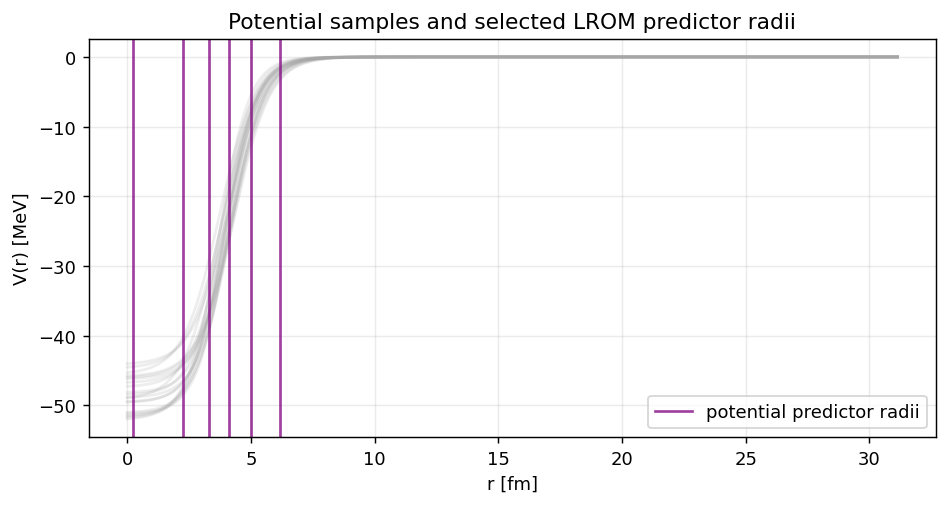

In [9]:
r3 = ws3_emulator.mesh.radius
fig, ax = plt.subplots(figsize=(7.4, 4.0))
for potential in ws3_emulator.samples.training_potentials[:20]:
    ax.plot(r3, np.real(potential), color="0.65", alpha=0.20)
for radius_index, selected_radius in enumerate(
    ws3_emulator.predictors.selected_radii, start=1
):
    ax.axvline(
        selected_radius,
        color="purple",
        alpha=0.75,
        label="potential predictor radii" if radius_index == 1 else None,
    )
ax.set(
    xlabel="r [fm]",
    ylabel="V(r) [MeV]",
    title="Potential samples and selected LROM predictor radii",
)
ax.legend()
fig.tight_layout()
plt.show()

The two rank-four bases are shown together before their coordinates.
LROM and LS use the central-reference basis; ROSE uses its
free-reference basis.

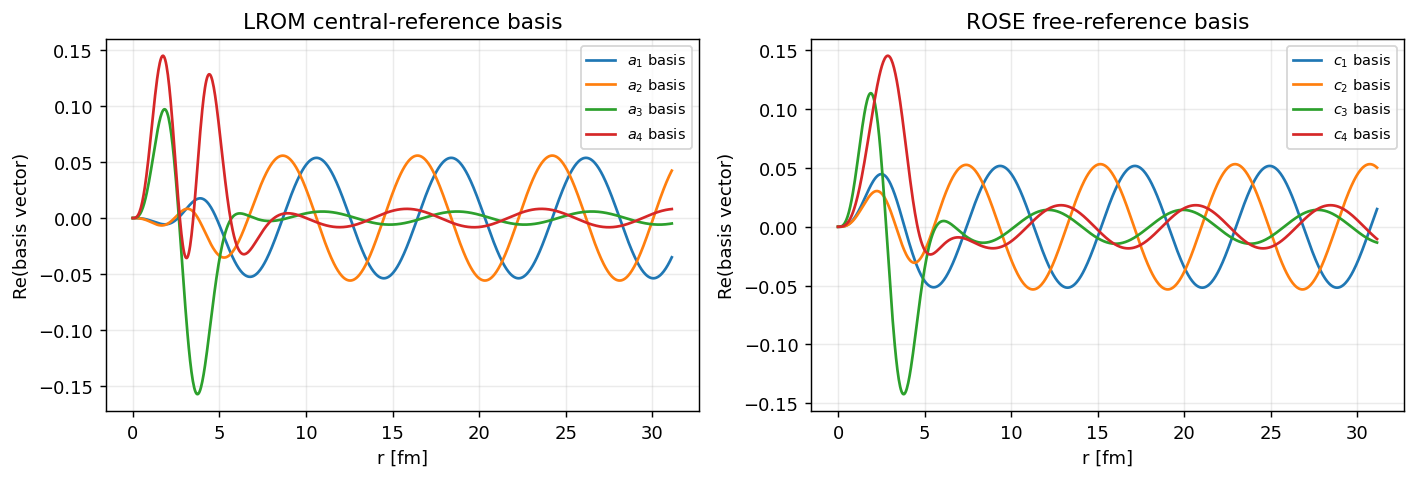

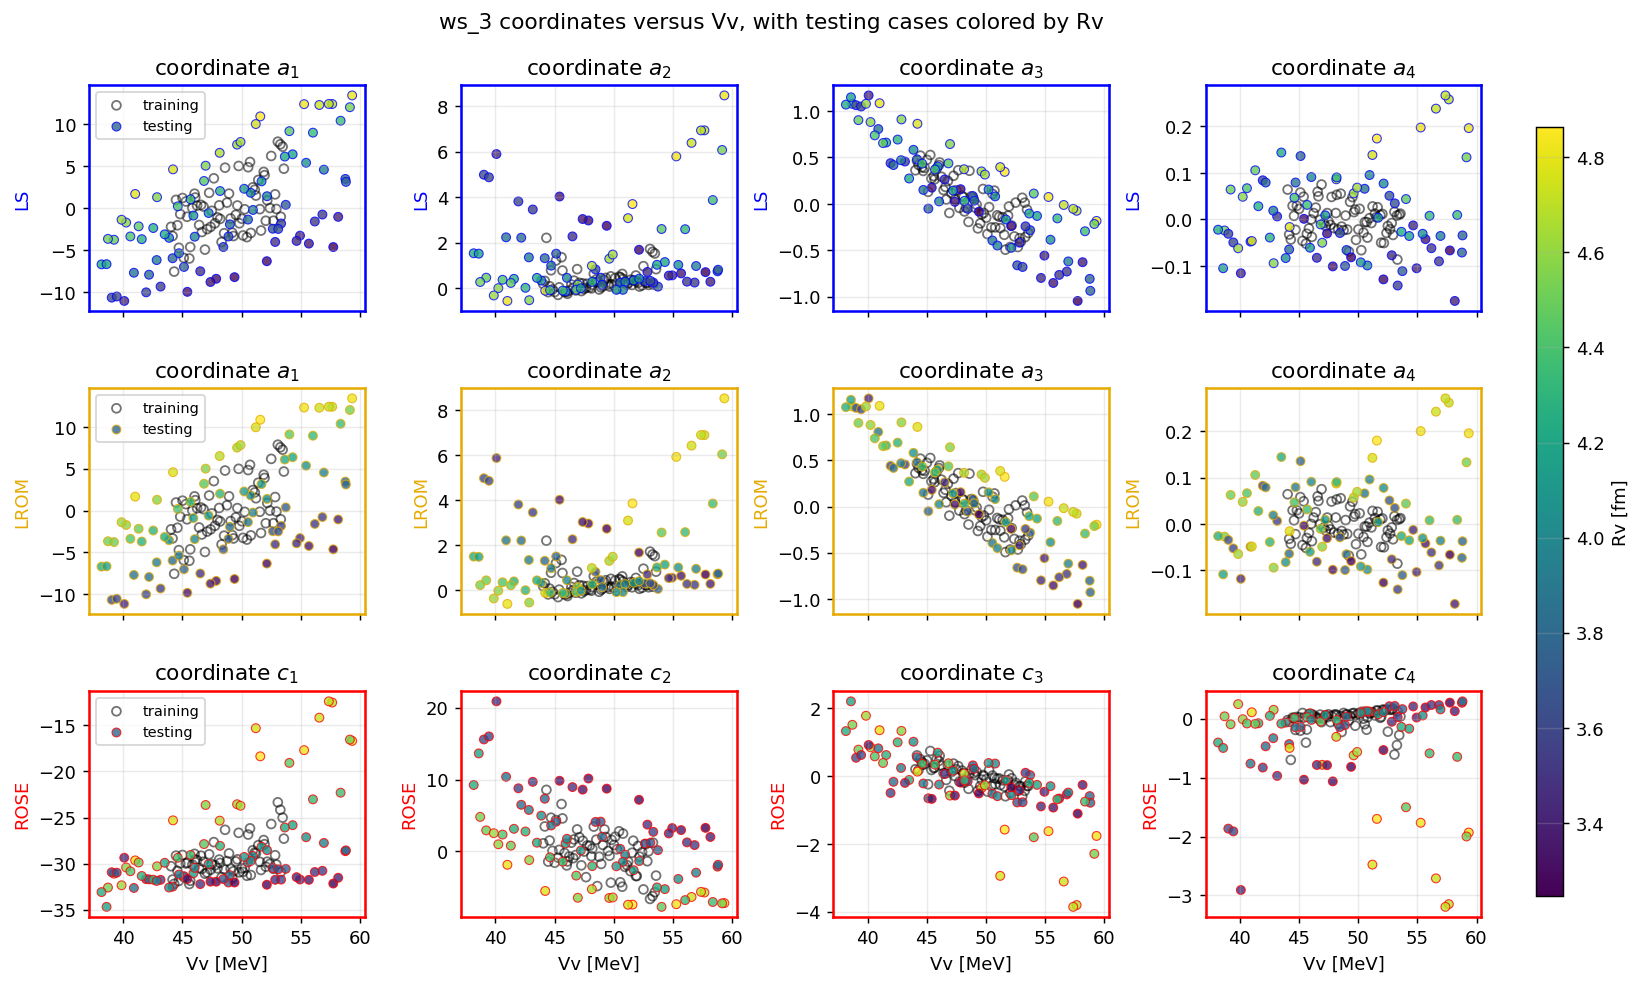

In [10]:
ws3_basis = ws3_emulator.basis[0]
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.8))
for coordinate_index in range(BASIS_SIZE):
    axes[0].plot(
        r3,
        np.real(ws3_basis.vectors[:, coordinate_index]),
        label=fr"$a_{{{coordinate_index + 1}}}$ basis",
    )
    axes[1].plot(
        r3,
        np.real(ws3_rose_basis.vectors[:, coordinate_index]),
        label=fr"$c_{{{coordinate_index + 1}}}$ basis",
    )
axes[0].set(
    xlabel="r [fm]",
    ylabel="Re(basis vector)",
    title="LROM central-reference basis",
)
axes[1].set(
    xlabel="r [fm]",
    ylabel="Re(basis vector)",
    title="ROSE free-reference basis",
)
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

# One shared coordinate figure keeps method and parameter comparisons
# aligned: rows are methods, columns are retained coordinates, and
# testing-point color records the second physical parameter Rv.
ws3_coordinate_data = {
    "LS": {
        "training": ws3_ls_train_coefficients,
        "testing": ws3_ls_coefficients,
        "symbol": "a",
        "color": METHOD_COLORS["ls"],
    },
    "LROM": {
        "training": np.asarray(
            ws3_emulator.training_results.coefficients["lrom"][0]
        ),
        "testing": np.asarray(
            ws3_emulator.testing_results.coefficients["lrom"][0]
        ),
        "symbol": "a",
        "color": METHOD_COLORS["lrom"],
    },
    "ROSE": {
        "training": ws3_rose_train_coefficients,
        "testing": ws3_rose_coefficients,
        "symbol": "c",
        "color": METHOD_COLORS["rose"],
    },
}
ws3_rv_norm = plt.Normalize(
    vmin=min(ws3_train_rows[:, 1].min(), ws3_test_rows[:, 1].min()),
    vmax=max(ws3_train_rows[:, 1].max(), ws3_test_rows[:, 1].max()),
)
fig, axes = plt.subplots(3, BASIS_SIZE, figsize=(14.0, 8.0), sharex="col")
for row_index, (method, coordinate_data) in enumerate(
    ws3_coordinate_data.items()
):
    for coordinate_index in range(BASIS_SIZE):
        ax = axes[row_index, coordinate_index]
        ax.scatter(
            ws3_train_rows[:, 0],
            np.real(coordinate_data["training"][:, coordinate_index]),
            s=24,
            marker="o",
            facecolors="none",
            edgecolors="black",
            alpha=0.55,
            label="training" if coordinate_index == 0 else None,
        )
        ax.scatter(
            ws3_test_rows[:, 0],
            np.real(coordinate_data["testing"][:, coordinate_index]),
            c=ws3_test_rows[:, 1],
            cmap="viridis",
            norm=ws3_rv_norm,
            s=24,
            alpha=0.8,
            edgecolors=coordinate_data["color"],
            linewidths=0.6,
            label="testing" if coordinate_index == 0 else None,
        )
        for spine in ax.spines.values():
            spine.set_color(coordinate_data["color"])
            spine.set_linewidth(1.4)
        ax.set_title(
            fr"coordinate ${coordinate_data['symbol']}_{{{coordinate_index + 1}}}$"
        )
        ax.set_ylabel(method, color=coordinate_data["color"])
        if row_index == len(ws3_coordinate_data) - 1:
            ax.set_xlabel("Vv [MeV]")
    axes[row_index, 0].legend(fontsize=8)
fig.subplots_adjust(top=0.91, right=0.89, hspace=0.34, wspace=0.35)
ws3_colorbar_ax = fig.add_axes([0.92, 0.13, 0.015, 0.74])
fig.colorbar(
    plt.cm.ScalarMappable(norm=ws3_rv_norm, cmap="viridis"),
    cax=ws3_colorbar_ax,
    label="Rv [fm]",
)
fig.suptitle(
    "ws_3 coordinates versus Vv, with testing cases colored by Rv"
)
plt.show()

## Section 3. Three-Parameter Wavefunction Emulation Results

The same method-neutral selection rule now chooses three ws_3 cases.
Distance from the central point is computed after scaling each active
parameter by its testing half-range, so Vv, Rv, and av contribute in
comparable units. The least-squares curve remains the attainable floor
for the fixed LROM basis.

,case_id,Vv [MeV],Rv [fm],av [fm],LS relative L2,LROM relative L2,ROSE relative L2
difficulty,,,,,,,
lower,test-0071,52.839130,3.475950,0.685658,0.003404,0.003405,0.039352
median,test-0007,44.172657,3.810442,0.753411,0.004062,0.004063,0.155777
upper,test-0044,59.151842,4.524825,0.746362,0.006419,0.008081,0.186351


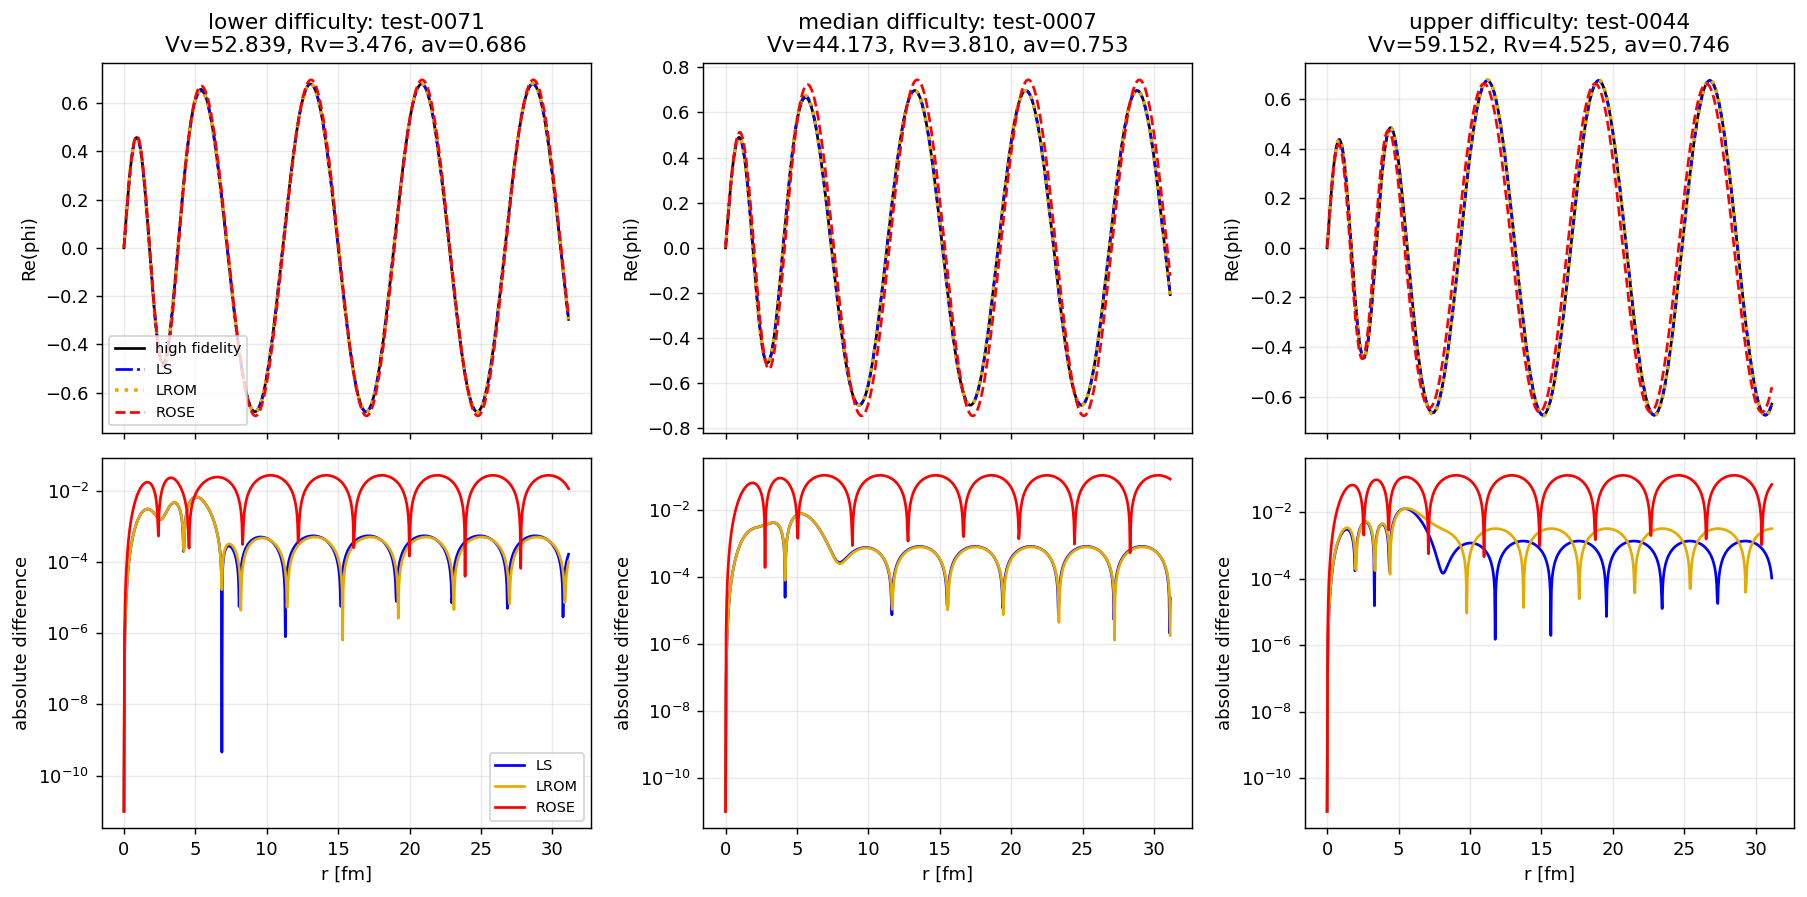

In [11]:
# Assemble aligned testing errors, one row per physical parameter row.
ws3_case_errors = np.column_stack((
    ws3_ls_rel_test,
    np.asarray(
        ws3_emulator.testing_results.metrics["relative_l2"][0]["lrom"]
    ),
    ws3_rose_rel_test,
))

# Normalize each coordinate by its testing half-range before measuring
# distance from the central physical point.
ws3_testing_half_ranges = np.asarray([
    0.5 * (ws3_testing_ranges[name][1] - ws3_testing_ranges[name][0])
    for name in ws3_emulator.parameter_names
])
ws3_selection_center_row = np.asarray([
    ws3_center[name] for name in ws3_emulator.parameter_names
])
ws3_normalized_distance = np.linalg.norm(
    (ws3_test_rows - ws3_selection_center_row)
    / ws3_testing_half_ranges,
    axis=1,
)
ws3_training_overlap = np.any(
    np.all(
        np.isclose(
            ws3_test_rows[:, None, :],
            ws3_train_rows[None, :, :],
            rtol=0.0,
            atol=1e-12,
        ),
        axis=2,
    ),
    axis=1,
)
ws3_candidate_indices = np.flatnonzero(
    (ws3_normalized_distance >= 0.25) & ~ws3_training_overlap
)
assert len(ws3_candidate_indices) >= 3

# Rank the eligible errors method by method, then average those ranks.
ws3_candidate_errors = ws3_case_errors[ws3_candidate_indices]
ws3_method_ranks = np.empty_like(ws3_candidate_errors, dtype=float)
for method_index in range(ws3_candidate_errors.shape[1]):
    method_order = np.argsort(
        ws3_candidate_errors[:, method_index], kind="stable"
    )
    ws3_method_ranks[method_order, method_index] = np.arange(
        len(ws3_candidate_indices)
    )
ws3_combined_rank = ws3_method_ranks.mean(axis=1)
ws3_difficulty_order = ws3_candidate_indices[
    np.argsort(ws3_combined_rank, kind="stable")
]
ws3_difficulty_quantiles = np.array([0.25, 0.50, 0.75])
ws3_selected_positions = np.rint(
    ws3_difficulty_quantiles * (len(ws3_difficulty_order) - 1)
).astype(int)
ws3_selected_indices = ws3_difficulty_order[ws3_selected_positions]
assert len(np.unique(ws3_selected_indices)) == 3
assert np.all(ws3_normalized_distance[ws3_selected_indices] >= 0.25)
assert not np.any(ws3_training_overlap[ws3_selected_indices])

# Check row identity explicitly before plotting the three matched cases.
ws3_selected_ids = np.asarray(
    ws3_emulator.samples.design.testing.case_ids
)[ws3_selected_indices]
ws3_difficulty_labels = ("lower", "median", "upper")
ws3_selected_records = []
for difficulty_label, selected_index, selected_id in zip(
    ws3_difficulty_labels, ws3_selected_indices, ws3_selected_ids
):
    ws3_case = ws3_emulator.testing_case(case_id=selected_id)
    case_row = np.asarray([
        ws3_case.parameters[name] for name in ws3_emulator.parameter_names
    ])
    assert np.allclose(case_row, ws3_test_rows[selected_index])
    ws3_selected_records.append({
        "difficulty": difficulty_label,
        "case_id": selected_id,
        "Vv [MeV]": float(ws3_test_rows[selected_index, 0]),
        "Rv [fm]": float(ws3_test_rows[selected_index, 1]),
        "av [fm]": float(ws3_test_rows[selected_index, 2]),
        "LS relative L2": float(ws3_case_errors[selected_index, 0]),
        "LROM relative L2": float(ws3_case_errors[selected_index, 1]),
        "ROSE relative L2": float(ws3_case_errors[selected_index, 2]),
    })
display(pd.DataFrame(ws3_selected_records).set_index("difficulty"))

fig, axes = plt.subplots(2, 3, figsize=(14.0, 7.0), sharex="col")
for column, (difficulty_label, selected_index, selected_id) in enumerate(
    zip(ws3_difficulty_labels, ws3_selected_indices, ws3_selected_ids)
):
    ws3_case = ws3_emulator.testing_case(case_id=selected_id)
    axes[0, column].plot(
        ws3_case.radius,
        np.real(ws3_case.high_fidelity[0]),
        color="black",
        label="high fidelity",
    )
    axes[0, column].plot(
        ws3_case.radius,
        np.real(ws3_ls_wf_test[selected_index]),
        "-.",
        color=METHOD_COLORS["ls"],
        label="LS",
    )
    axes[0, column].plot(
        ws3_case.radius,
        np.real(ws3_case.lrom[0]),
        ":",
        color=METHOD_COLORS["lrom"],
        linewidth=2,
        label="LROM",
    )
    axes[0, column].plot(
        ws3_case.radius,
        np.real(ws3_rose_wf_test[selected_index]),
        "--",
        color=METHOD_COLORS["rose"],
        label="ROSE",
    )
    parameter_text = ", ".join(
        f"{name}={value:.3f}"
        for name, value in zip(
            ws3_emulator.parameter_names, ws3_test_rows[selected_index]
        )
    )
    axes[0, column].set(
        ylabel="Re(phi)",
        title=(
            f"{difficulty_label} difficulty: {selected_id}\n"
            f"{parameter_text}"
        ),
    )
    axes[1, column].plot(
        ws3_case.radius,
        np.maximum(
            np.abs(
                ws3_case.high_fidelity[0]
                - ws3_ls_wf_test[selected_index]
            ),
            DISPLAY_ERROR_FLOOR,
        ),
        color=METHOD_COLORS["ls"],
        label="LS",
    )
    axes[1, column].plot(
        ws3_case.radius,
        np.maximum(
            np.abs(ws3_case.high_fidelity[0] - ws3_case.lrom[0]),
            DISPLAY_ERROR_FLOOR,
        ),
        color=METHOD_COLORS["lrom"],
        label="LROM",
    )
    axes[1, column].plot(
        ws3_case.radius,
        np.maximum(
            np.abs(
                ws3_case.high_fidelity[0]
                - ws3_rose_wf_test[selected_index]
            ),
            DISPLAY_ERROR_FLOOR,
        ),
        color=METHOD_COLORS["rose"],
        label="ROSE",
    )
    axes[1, column].set_yscale("log")
    axes[1, column].set(
        xlabel="r [fm]",
        ylabel="absolute difference",
    )
axes[0, 0].legend(fontsize=8)
axes[1, 0].legend(fontsize=8)
fig.tight_layout()
plt.show()

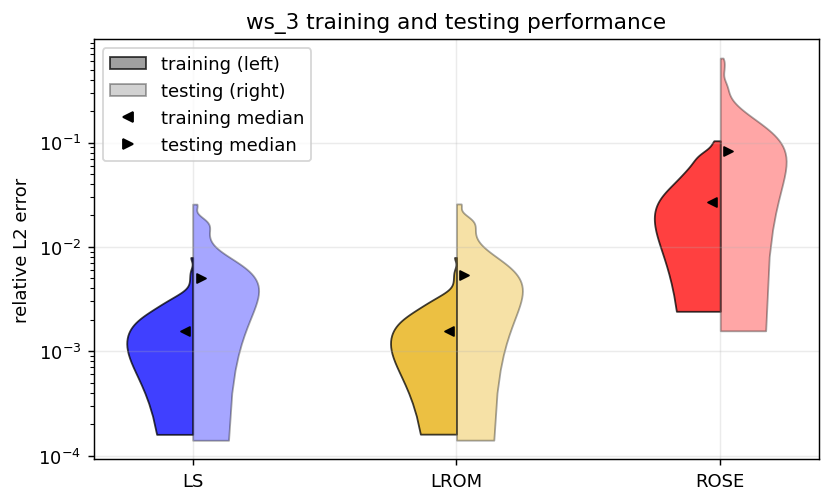

In [12]:
methods = ("ls", "lrom", "rose")
colors = tuple(METHOD_COLORS[method] for method in methods)
positions = np.arange(1, 4)
training_metrics = dict(ws3_emulator.training_results.metrics["relative_l2"][0])
training_metrics["ls"] = ws3_ls_rel_train
training_metrics["rose"] = ws3_rose_rel_train
testing_metrics = dict(ws3_emulator.testing_results.metrics["relative_l2"][0])
testing_metrics["ls"] = ws3_ls_rel_test
testing_metrics["rose"] = ws3_rose_rel_test
training_values = [
    np.maximum(training_metrics[method], np.finfo(float).tiny)
    for method in methods
]
testing_values = [
    np.maximum(testing_metrics[method], np.finfo(float).tiny)
    for method in methods
]
fig, ax = plt.subplots(figsize=(7.2, 4.2))
training_violin = ax.violinplot(
    training_values,
    positions=positions,
    showextrema=False,
)
testing_violin = ax.violinplot(
    testing_values,
    positions=positions,
    showextrema=False,
)
for center, body, color in zip(positions, training_violin["bodies"], colors):
    vertices = body.get_paths()[0].vertices
    vertices[:, 0] = np.minimum(vertices[:, 0], center)
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.75)
for center, body, color in zip(positions, testing_violin["bodies"], colors):
    vertices = body.get_paths()[0].vertices
    vertices[:, 0] = np.maximum(vertices[:, 0], center)
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.35)
ax.scatter(positions - 0.03, [np.median(values) for values in training_values], color="black", marker="<", s=24)
ax.scatter(positions + 0.03, [np.median(values) for values in testing_values], color="black", marker=">", s=24)
ax.set_xticks(positions, [method.upper() for method in methods])
ax.set_yscale("log")
ax.set_ylabel("relative L2 error")
ax.set_title("ws_3 training and testing performance")
ax.legend(handles=[
    Patch(facecolor="gray", edgecolor="black", alpha=0.75, label="training (left)"),
    Patch(facecolor="gray", edgecolor="black", alpha=0.35, label="testing (right)"),
    Line2D([], [], color="black", marker="<", linestyle="None", label="training median"),
    Line2D([], [], color="black", marker=">", linestyle="None", label="testing median"),
])
plt.show()

In [13]:
test_values = ws3_emulator.samples.design.testing.values
names = ws3_emulator.parameter_names
interpolation = np.ones(len(test_values), dtype=bool)
for column, name in enumerate(names):
    low, high = ws3_training_ranges[name]
    interpolation &= (test_values[:, column] >= low) & (test_values[:, column] <= high)

rows = []
metrics = dict(ws3_emulator.testing_results.metrics["relative_l2"][0])
metrics["ls"] = ws3_ls_rel_test
metrics["rose"] = ws3_rose_rel_test
for region, mask in (("interpolation", interpolation), ("extrapolation", ~interpolation)):
    for method in ("rose", "lrom", "ls"):
        values = metrics[method][mask]
        rows.append(
            {
                "region": region,
                "method": method.upper(),
                "cases": int(mask.sum()),
                "median relative L2": float(np.median(values)),
                "maximum relative L2": float(np.max(values)),
            }
        )
pd.DataFrame(rows).set_index(["region", "method"])

cases  median relative L2  maximum relative L2
region        method                                                
interpolation ROSE        9            0.028529             0.096289
              LROM        9            0.001462             0.003065
              LS          9            0.001449             0.003064
extrapolation ROSE       72            0.094605             0.644166
              LROM       72            0.005726             0.025802
              LS         72            0.005419             0.025691

In [14]:
artifact_path = ROOT / "outputs" / "notebook01_ws3_model.lrom"
ws3_emulator.save(path=artifact_path)
portable_emulator = lrom.load(path=artifact_path)
ws3_export_case = ws3_emulator.testing_case(
    case_id=ws3_selected_ids[1]
)
portable_emulator.predict(parameters=ws3_export_case.parameters)
print("portable model:", artifact_path)
print("prediction shape:", portable_emulator.predictions.wavefunctions[0].shape)

portable model: /Users/Kitkat/Documents/Documents-Agent/LROM_Project/outputs/notebook01_ws3_model.lrom
prediction shape: (1, 800)
